In [2]:
# IMC documentation pre-defined time calculation functions
TRADING_DAYS_PER_YEAR = 252
STEPS_PER_DAY = 4
STEPS_PER_YEAR = TRADING_DAYS_PER_YEAR * STEPS_PER_DAY

def weeks_to_years(weeks: float) -> float:
    # 5 business days per week, annualized to 252 trading days
    return (weeks * 5) / TRADING_DAYS_PER_YEAR

def steps_from_weeks(weeks: float) -> int:
    return int(round(weeks * 5 * STEPS_PER_DAY))

In [12]:
import numpy as np
# predefined constants
VOLATILITY = 2.51
r=0
DT = 1 / (252*4)
MID_PRICE_AETHER = (50.025 + 49.975) / 2

products = {
        "AC": {
            "type": "underlying",
            "weeks": 2,
            "bid": 50.025,
            "ask": 49.975,
            "volume": 200
        },
        "AC_50_P": {
            "type": "put",
            "K": 50,
            "weeks": 3,
            "bid": 12,
            "ask": 12.05,
            "volume": 50
        },
        "AC_50_C": {
            "type": "call",
            "K": 50,
            "weeks": 3,
            "bid": 12,
            "ask": 12.05,
            "volume": 50
        },

        "AC_35_P": {
            "type": "put",
            "K": 35,
            "weeks": 3,
            "bid": 4.33,
            "ask": 4.35,
            "volume": 50
        },

        "AC_40_P": {
            "type": "put",
            "K": 40,
            "weeks": 3,
            "bid": 6.5,
            "ask": 6.55,
            "volume": 50
        },

        "AC_45_P": {
            "type": "put",
            "K": 45,
            "weeks": 3,
            "bid": 9.05,
            "ask": 9.1,
            "volume": 50
        },

        "AC_60_C": {
            "type": "call",
            "K": 60,
            "weeks": 3,
            "bid": 8.8,
            "ask": 8.85,
            "volume": 50
        },

        "AC_50_P_2": {
            "type": "put",
            "K": 50,
            "weeks": 2,
            "bid": 9.7,
            "ask": 9.75,
            "volume": 50
        },

        "AC_50_C_2": {
            "type": "call",
            "K": 50,
            "weeks": 2,
            "bid": 9.7,
            "ask": 9.75,
            "volume": 50
        },
        "AC_45_KO": {
            "type": "knockout_put",
            "K": 45,
            "barrier": 35,
            "weeks": 3,
            "bid": 0.15,
            "ask": 0.175,
            "volume": 500
        },

        "AC_40_BP": {
            "type": "binary_put",
            "K": 40,
            "weeks": 3,
            "bid": 5,
            "ask": 5.1,
            "volume": 50,
            "payout": 10
        },
        "AC_50_CHOOSER": {
            "type": "chooser",
            "K": 50,
            "weeks": 3,
            "bid": 22.2,
            "ask": 22.3,
            "volume": 50
        },
}

In [125]:
import numpy as np

VOL = 2.51
DT = 1 / (252 * 4)
STEPS_PER_WEEK = 5 * 4  # 5 days * 4 steps
S0 = 50.0
CONTRACT_SIZE = 3000

products = {
    "AC": {"type": "underlying", "bid": 50.025, "ask": 49.975},

    "AC_50_P": {"type": "put", "K": 50, "weeks": 3, "bid": 12, "ask": 12.05},
    "AC_50_C": {"type": "call", "K": 50, "weeks": 3, "bid": 12, "ask": 12.05},

    "AC_35_P": {"type": "put", "K": 35, "weeks": 3, "bid": 4.33, "ask": 4.35},
    "AC_40_P": {"type": "put", "K": 40, "weeks": 3, "bid": 6.5, "ask": 6.55},
    "AC_45_P": {"type": "put", "K": 45, "weeks": 3, "bid": 9.05, "ask": 9.1},

    "AC_60_C": {"type": "call", "K": 60, "weeks": 3, "bid": 8.8, "ask": 8.85},

    "AC_50_P_2": {"type": "put", "K": 50, "weeks": 2, "bid": 9.7, "ask": 9.75},
    "AC_50_C_2": {"type": "call", "K": 50, "weeks": 2, "bid": 9.7, "ask": 9.75},

    "AC_45_KO": {"type": "knockout_put", "K": 45, "barrier": 35, "weeks": 3, "bid": 0.15, "ask": 0.175},

    "AC_40_BP": {"type": "binary_put", "K": 40, "weeks": 3, "bid": 5, "ask": 5.1, "payout": 10},

    "AC_50_CHOOSER": {"type": "chooser", "K": 50, "weeks": 3, "bid": 22.2, "ask": 22.3},
}

def simulate_paths(n_paths, steps):
    Z = np.random.normal(size=(n_paths, steps))
    increments = ( -0.5 * VOL**2 * DT + VOL * np.sqrt(DT) * Z )
    log_paths = np.cumsum(increments, axis=1)
    S = S0 * np.exp(log_paths)
    return S


def payoff(product, paths):
    if product["type"] == "underlying":
        return paths[:, -1]  # full horizon terminal price

    T_steps = product.get("weeks", 0) * STEPS_PER_WEEK
    sub_paths = paths[:, :T_steps]
    S_T = sub_paths[:, -1]

    t = product["type"]

    if t == "underlying":
        return S_T

    if t == "call":
        return np.maximum(S_T - product["K"], 0)

    if t == "put":
        return np.maximum(product["K"] - S_T, 0)

    if t == "binary_put":
        return np.where(S_T < product["K"], product["payout"], 0)

    if t == "knockout_put":
        breached = np.any(sub_paths <= product["barrier"], axis=1)
        vanilla = np.maximum(product["K"] - S_T, 0)
        return np.where(breached, 0, vanilla)

    if t == "chooser":
        # decision at 2 weeks
        t2 = 2 * STEPS_PER_WEEK
        S_mid = paths[:, t2 - 1]

        call_payoff = np.maximum(S_T - product["K"], 0)
        put_payoff = np.maximum(product["K"] - S_T, 0)

        choose_call = S_mid > product["K"]
        return np.where(choose_call, call_payoff, put_payoff)

    raise ValueError("Unknown product")


def evaluate_strategy(strategy, paths):
    total_pnl = 0.0

    for name, position in strategy.items():
        product = products[name]

        pay = payoff(product, paths)
        fair_value = np.mean(pay)

        price = product["ask"] if position > 0 else product["bid"]

        pnl = position * (fair_value - price) * CONTRACT_SIZE
        total_pnl += pnl

    return total_pnl


def run_simulation(strategy, N_runs=50, paths_per_run=100):
    results = []

    max_weeks = max(p.get("weeks", 0) for p in products.values())
    total_steps = max_weeks * STEPS_PER_WEEK

    for _ in range(N_runs):
        paths = simulate_paths(paths_per_run, total_steps)
        pnl = evaluate_strategy(strategy, paths)
        results.append(pnl)

    return {
        "mean_pnl": np.mean(results),
        "std_pnl": np.std(results),
        "all_runs": results
    }


strategy = {
    "AC_50_P_2": 50,
    "AC_50_C_2": 50,
    "AC_45_KO": 500,
    "AC_40_BP": -50,
    "AC_50_CHOOSER": -50,
}

if __name__ == "__main__":
    res = run_simulation(strategy, N_runs=10000, paths_per_run=100)

    print("Mean PnL:", res["mean_pnl"])
    print("Std PnL:", res["std_pnl"])

Mean PnL: 162594.6119201211
Std PnL: 343040.51705246547


(array([1.000e+00, 1.500e+01, 1.220e+02, 7.190e+02, 2.313e+03, 3.382e+03,
        2.429e+03, 8.550e+02, 1.470e+02, 1.700e+01]),
 array([-1.49637475e+06, -1.19723614e+06, -8.98097525e+05, -5.98958910e+05,
        -2.99820296e+05, -6.81681271e+02,  2.98456933e+05,  5.97595548e+05,
         8.96734163e+05,  1.19587278e+06,  1.49501139e+06]),
 <BarContainer object of 10 artists>)

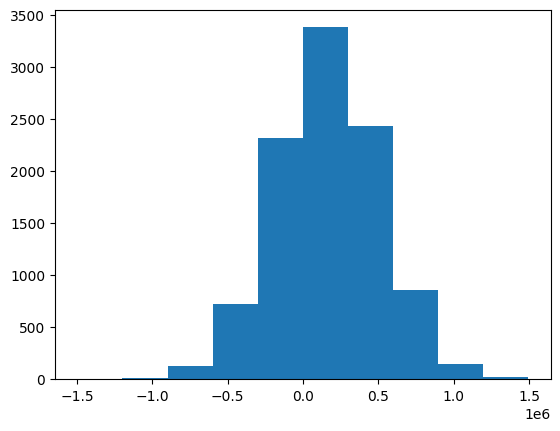

In [126]:
import matplotlib.pyplot as plt

plt.hist(res["all_runs"])

In [127]:
dist_mean = np.mean(res["all_runs"])
dist_std = np.std(res["all_runs"])

benchmarks = [0, 50, 75, 100, 150, 200, 300, 400]

for benchmark in benchmarks:
  p = 1 - norm.cdf(benchmark*1000, loc=dist_mean, scale=dist_std) # P(x > 0)
  print("Probability of > " + str(benchmark*1000) + ": " + str(p*100) + "%")

Probability of > 0: 68.22431935149737%
Probability of > 50000: 62.862937895721814%
Probability of > 75000: 60.07727248020075%
Probability of > 100000: 57.23930622138782%
Probability of > 150000: 51.46437355495195%
Probability of > 200000: 45.65850928941534%
Probability of > 300000: 34.43751858137748%
Probability of > 400000: 24.44491222317139%
